# **Importing Libraries**

In [77]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.metrics import *
from imblearn.metrics import *
from sklearn.impute import *

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# importing classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

# **Loading the Dataset**
Dataset Link: [Formula 1 Drivers Dataset](https://www.kaggle.com/datasets/dubradave/formula-1-drivers-dataset)

We will do our works keeping in mind to create a model for predicting whether a rookie F1 driver will be future champion or not

In [4]:
data=pd.read_csv('/content/drive/MyDrive/Temp/F1DriversDataset.csv')
data

,Driver,Nationality,Seasons,Championships,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,...,Championship Years,Decade,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active,Champion
0,Carlo Abate,Italy,"[1962, 1963]",0,3,0,0,0,0,0,...,NaN,1960,0.0,0.000000,0.0,0.0,0.000000,0.000000,2,False
1,George Abecassis,United Kingdom,"[1951, 1952]",0,2,2,0,0,0,0,...,NaN,1950,0.0,1.000000,0.0,0.0,0.000000,0.000000,2,False
2,Kenny Acheson,United Kingdom,"[1983, 1985]",0,10,3,0,0,0,0,...,NaN,1980,0.0,0.300000,0.0,0.0,0.000000,0.000000,2,False
3,Andrea de Adamich,Italy,"[1968, 1970, 1971, 1972, 1973]",0,36,30,0,0,0,0,...,NaN,1970,0.0,0.833333,0.0,0.0,0.000000,0.166667,5,False
4,Philippe Adams,Belgium,[1994],0,2,2,0,0,0,0,...,NaN,1990,0.0,1.000000,0.0,0.0,0.000000,0.000000,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,Emilio Zapico,Spain,[1976],0,1,0,0,0,0,0,...,NaN,1980,0.0,0.000000,0.0,0.0,0.000000,0.000000,1,False
864,Zhou Guanyu,China,[2022],0,23,23,0,0,0,2,...,NaN,2020,0.0,1.000000,0.0,0.0,0.086957,0.260870,1,False
865,Ricardo Zonta,Brazil,"[1999, 2000, 2001, 2004, 2005]",0,37,36,0,0,0,0,...,NaN,2000,0.0,0.972973,0.0,0.0,0.000000,0.081081,5,False
866,Renzo Zorzi,Italy,"[1975, 1976, 1977]",0,7,7,0,0,0,0,...,NaN,1980,0.0,1.000000,0.0,0.0,0.000000,0.142857,3,False


In [5]:
data.isnull().sum()

,0
Driver,0
Nationality,0
Seasons,0
Championships,0
Race_Entries,0
Race_Starts,0
Pole_Positions,0
Race_Wins,0
Podiums,0
Fastest_Laps,0


# **Removing Unnecessary Features**
Before performing feature selection, we will remove those attributes which are obvious for not contributing to predict whether a rookie F1 driver will be champion or not

In [25]:
data1=data.drop(['Driver','Nationality','Seasons','Championships','Championship Years','Active','Decade'],axis=1)
data1

,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,Points,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active,Champion
0,3,0,0,0,0,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,2,False
1,2,2,0,0,0,0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.000000,2,False
2,10,3,0,0,0,0,0.0,0.0,0.300000,0.0,0.0,0.000000,0.000000,2,False
3,36,30,0,0,0,0,6.0,0.0,0.833333,0.0,0.0,0.000000,0.166667,5,False
4,2,2,0,0,0,0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.000000,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,1,0,0,0,0,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,1,False
864,23,23,0,0,0,2,6.0,0.0,1.000000,0.0,0.0,0.086957,0.260870,1,False
865,37,36,0,0,0,0,3.0,0.0,0.972973,0.0,0.0,0.000000,0.081081,5,False
866,7,7,0,0,0,0,1.0,0.0,1.000000,0.0,0.0,0.000000,0.142857,3,False


In [26]:
#mapping target varibale to 0 or 1
data1['Champion']=data1['Champion'].map({True:1,False:0})
data1

,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,Points,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active,Champion
0,3,0,0,0,0,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,2,0
1,2,2,0,0,0,0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.000000,2,0
2,10,3,0,0,0,0,0.0,0.0,0.300000,0.0,0.0,0.000000,0.000000,2,0
3,36,30,0,0,0,0,6.0,0.0,0.833333,0.0,0.0,0.000000,0.166667,5,0
4,2,2,0,0,0,0,0.0,0.0,1.000000,0.0,0.0,0.000000,0.000000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,1,0,0,0,0,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,1,0
864,23,23,0,0,0,2,6.0,0.0,1.000000,0.0,0.0,0.086957,0.260870,1,0
865,37,36,0,0,0,0,3.0,0.0,0.972973,0.0,0.0,0.000000,0.081081,5,0
866,7,7,0,0,0,0,1.0,0.0,1.000000,0.0,0.0,0.000000,0.142857,3,0


In [27]:
data1.columns.values

array(['Race_Entries', 'Race_Starts', 'Pole_Positions', 'Race_Wins',
       'Podiums', 'Fastest_Laps', 'Points', 'Pole_Rate', 'Start_Rate',
       'Win_Rate', 'Podium_Rate', 'FastLap_Rate', 'Points_Per_Entry',
       'Years_Active', 'Champion'], dtype=object)

In [28]:
y=data1['Champion']
x=data1.drop(['Champion'],axis=1)

In [29]:
x.head()

,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,Points,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active
0,3,0,0,0,0,0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,2
1,2,2,0,0,0,0,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,2
2,10,3,0,0,0,0,0.0,0.0,0.300000,0.0,0.0,0.0,0.000000,2
3,36,30,0,0,0,0,6.0,0.0,0.833333,0.0,0.0,0.0,0.166667,5
4,2,2,0,0,0,0,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,1


In [30]:
y.head()

,Champion
0,0
1,0
2,0
3,0
4,0


In [92]:
#splitting in train test if needed later
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=25)

# **Feature Selection**

**Filter Methods:**

**Correlation Test:**
Selects features based on their correlation with the target variable (linear relationship)

<Axes: >

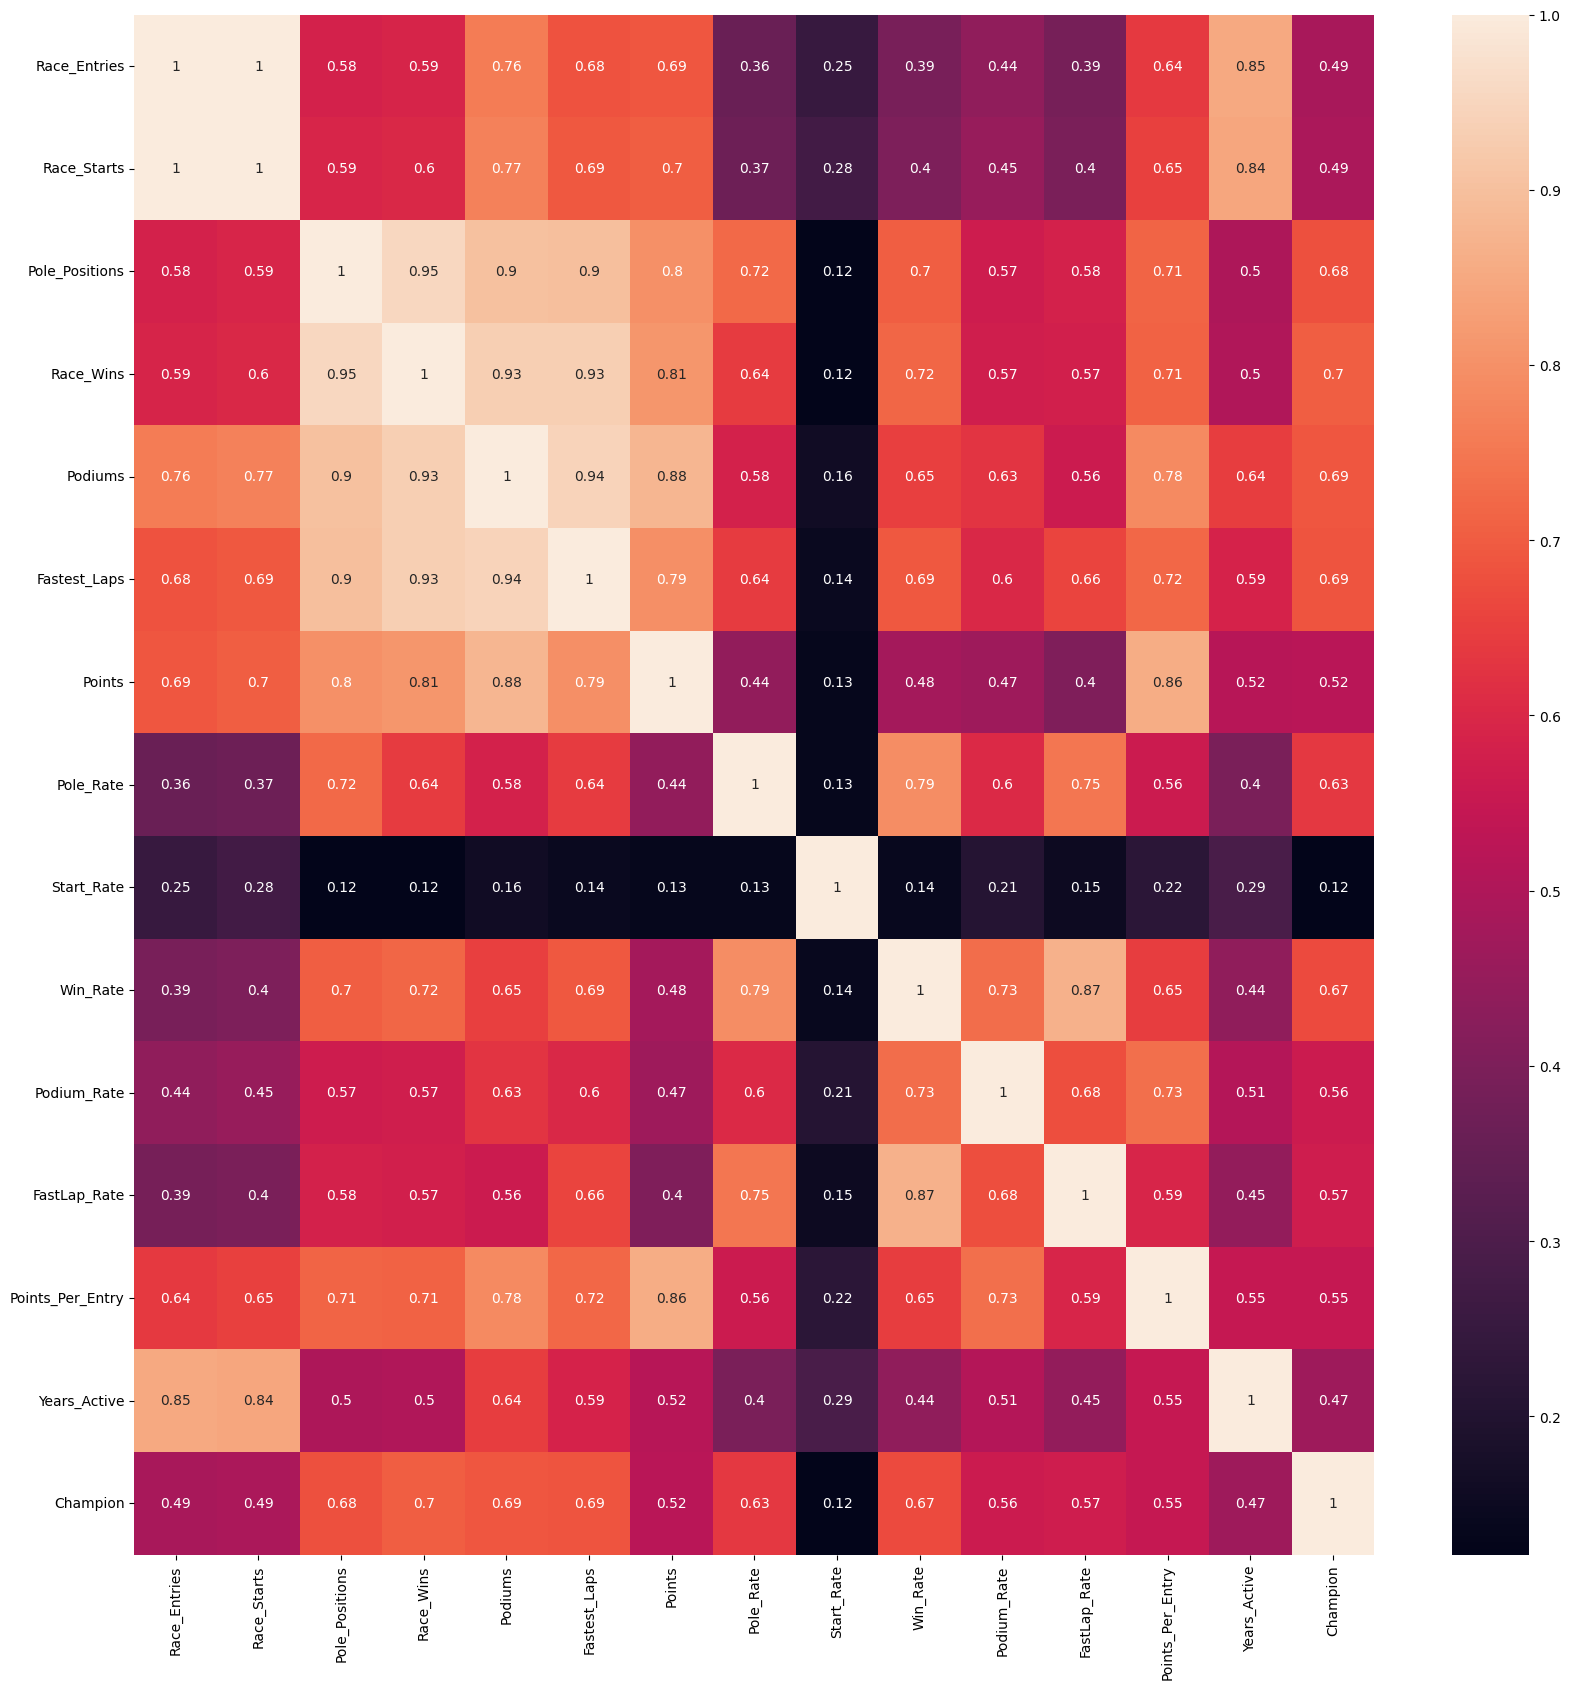

In [35]:
plt.figure(figsize=(20,20))
sns.heatmap(data1.corr(),annot=True)

In [43]:
correlation_with_target = x.corrwith(y)
threshold = 0.5

# Selecting features with correlation above the threshold
selected_features = correlation_with_target[abs(correlation_with_target) > threshold].index
selected_features_correleation=list(selected_features)


Selected features based on correlation with target:
['Pole_Positions', 'Race_Wins', 'Podiums', 'Fastest_Laps', 'Points', 'Pole_Rate', 'Win_Rate', 'Podium_Rate', 'FastLap_Rate', 'Points_Per_Entry']


From the Heatmap we can see (Racewin,Fastest Lap) , (Racewin,Podiums),(pole position, racewin), (fastest lap, pole position)...These pairs are highly correlated. So, we can also remove the 'Race_Wins' and 'Fastest_Laps' feature

In [44]:
selected_features_correleation.remove('Race_Wins')
selected_features_correleation.remove('Fastest_Laps')
# Printing the selected features
print("\nSelected features based on correlation with target:")
print(selected_features_correleation)


Selected features based on correlation with target:
['Pole_Positions', 'Podiums', 'Points', 'Pole_Rate', 'Win_Rate', 'Podium_Rate', 'FastLap_Rate', 'Points_Per_Entry']


**Chi2 Test:**
Selects features using the Chi-Square test, which measures the dependency between categorical features and the target.

In [45]:
from sklearn.feature_selection import chi2
chi2_stats, p_values = chi2(x, y)

In [50]:
# we will be selecting top k features based on chi2_stats
k=8
selected_features_chi2 = x.columns[np.argsort(chi2_stats)[-k:]]
selected_features_chi2=list(selected_features_chi2)
selected_features_chi2

['Points_Per_Entry',
 'Fastest_Laps',
 'Pole_Positions',
 'Race_Wins',
 'Race_Entries',
 'Race_Starts',
 'Podiums',
 'Points']

**Mutual Info:**
Selects features based on Mutual Information, which captures both linear and non-linear relationships between features and the target.

In [62]:
from sklearn.datasets import make_classification
from sklearn.feature_selection import mutual_info_classif
mi_scores=mutual_info_classif(x, y)

mi_scores=pd.Series(mi_scores, name="MI Scores", index=x.columns)
mi_scores = mi_scores.sort_values(ascending=False)

In [65]:
#selecting best K features
k=8
selected_features_mutual=mi_scores[:k]
selected_features_mutual=list(selected_features_mutual.index)
selected_features_mutual

['Race_Wins',
 'Podiums',
 'Win_Rate',
 'Pole_Positions',
 'Fastest_Laps',
 'Points',
 'Pole_Rate',
 'Podium_Rate']

**Anova Test:**
Selects features using ANOVA F-statistic, which measures the difference in means between groups for continuous features and categorical targets

In [70]:
from sklearn.datasets import make_classification
from sklearn.feature_selection import f_classif
f_scores, p_values = f_classif(x, y)
f_score_data=pd.Series(f_scores, name="F Scores", index=x.columns)
f_score_data = f_score_data.sort_values(ascending=False)

In [72]:
#selecting best K features
k=8
selected_features_anova=f_score_data[:k]
selected_features_anova
selected_features_anova=list(selected_features_anova.index)
selected_features_anova

['Race_Wins',
 'Podiums',
 'Fastest_Laps',
 'Pole_Positions',
 'Win_Rate',
 'Pole_Rate',
 'FastLap_Rate',
 'Podium_Rate']

***Wrapper Methods:***


**RFECV (Recursive Feature Elimination):**
Recursive Feature Elimination with Cross-Validation; recursively removes features and selects the optimal subset based on model performance.

In [87]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, roc_auc_score

sk = StratifiedKFold(shuffle=True, random_state=25, n_splits=10)
svc = SVC(random_state=25, kernel='linear')

rfecv = RFECV(estimator=svc, step=1, cv=sk, scoring=make_scorer(roc_auc_score), n_jobs=-1, min_features_to_select=8)

rfecv.fit(x, y)

RFECV(cv=StratifiedKFold(n_splits=10, random_state=25, shuffle=True),
      estimator=SVC(kernel='linear', random_state=25), min_features_to_select=8,
      n_jobs=-1, scoring=make_scorer(roc_auc_score, response_method='predict'))

In [89]:
selected_features_rfecv = list(x.columns[rfecv.support_])
selected_features_rfecv

['Race_Wins',
 'Fastest_Laps',
 'Pole_Rate',
 'Start_Rate',
 'Win_Rate',
 'Podium_Rate',
 'Points_Per_Entry',
 'Years_Active']

**SFS (Sequenctial Forward Selection):**
Sequential Forward Selection; iteratively adds the best feature to the subset until performance no longer improves.

In [91]:
!pip install mlxtend

from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [138]:
model = RandomForestClassifier(random_state=25)

# Initialize SFS
sfs = SequentialFeatureSelector(
    estimator=svc,
    k_features=8,  # Number of features to select
    forward=True,   # Forward selection (set to False for backward selection)
    scoring='accuracy',
    cv=5            # 5-fold cross-validation
)


In [139]:
#Fit SFS
sfs.fit(x_train, y_train)

SequentialFeatureSelector(estimator=SVC(kernel='linear', random_state=25),
                          k_features=(8, 8), scoring='accuracy')

In [140]:
# Getting the selected feature indices
selected_features = sfs.k_feature_idx_
print("Selected feature indices:", selected_features)

Selected feature indices: (0, 1, 3, 4, 7, 8, 9, 10)


In [141]:
selected_features_sfs=list(x.columns.values[list(selected_features)])
selected_features_sfs

['Race_Entries',
 'Race_Starts',
 'Race_Wins',
 'Podiums',
 'Pole_Rate',
 'Start_Rate',
 'Win_Rate',
 'Podium_Rate']

***Embedded Methods:***


**Decesion Tree**
Uses feature importance scores from a decision tree to select the most relevant features.

In [113]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=25)
model.fit(x, y)

DecisionTreeClassifier(random_state=25)

In [115]:
# Getting feature importances
feature_importances = model.feature_importances_

ranked_features = np.argsort(feature_importances)[::-1]

# Selecting top k features
k = 8
selected_features = ranked_features[:k]

selected_features_decesion_tree=list(x.columns.values[list(selected_features)])
selected_features_decesion_tree

['Race_Wins',
 'Points',
 'Win_Rate',
 'FastLap_Rate',
 'Fastest_Laps',
 'Start_Rate',
 'Pole_Rate',
 'Podium_Rate']

**L1 Regularization:**
Uses Lasso regression to shrink less important feature coefficients to zero, effectively performing feature selection.

In [123]:
model = LogisticRegression(penalty='l1', solver='liblinear', random_state=25)
model.fit(x, y)

# Getting the coefficients
coefficients = model.coef_[0]

# Select non-zero coefficients (selected features)
selected_features = np.where(coefficients != 0)[0]

selected_features_l1_regularization=list(x.columns.values[list(selected_features)])
selected_features_l1_regularization

['Race_Entries',
 'Race_Starts',
 'Race_Wins',
 'Podiums',
 'Fastest_Laps',
 'Points',
 'Points_Per_Entry',
 'Years_Active']

**Gradient Boosting:**
 Uses feature importance scores from a gradient boosting model to select the most relevant features.

In [128]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(random_state=25)
model.fit(x, y)

# Getting feature importances
feature_importances = model.feature_importances_

# Ranking features by importance
ranked_features = np.argsort(feature_importances)[::-1]

# Selecting top k features
k = 8
selected_features = ranked_features[:k]

selected_features_gradient_boosting=list(x.columns.values[selected_features])
selected_features_gradient_boosting

['Race_Wins',
 'Win_Rate',
 'Points',
 'Podiums',
 'Pole_Positions',
 'Start_Rate',
 'Pole_Rate',
 'Fastest_Laps']

# **Summarising all Selected Features through different approches**

In [142]:
selected_features={ 'Correlation':selected_features_correleation,
                    'Chi2':selected_features_chi2,
                    'Mutual Info':selected_features_mutual,
                    'Anova':selected_features_anova,
                    'RFECV':selected_features_rfecv,
                    'SFS':selected_features_sfs,
                    'Decesion Tree':selected_features_decesion_tree,
                    'L1 Regularization':selected_features_l1_regularization,
                    'Gradient Boosting':selected_features_gradient_boosting
                    }

selected_features_df=pd.DataFrame(selected_features)
selected_features_df

,Correlation,Chi2,Mutual Info,Anova,RFECV,SFS,Decesion Tree,L1 Regularization,Gradient Boosting
0,Pole_Positions,Points_Per_Entry,Race_Wins,Race_Wins,Race_Wins,Race_Entries,Race_Wins,Race_Entries,Race_Wins
1,Podiums,Fastest_Laps,Podiums,Podiums,Fastest_Laps,Race_Starts,Points,Race_Starts,Win_Rate
2,Points,Pole_Positions,Win_Rate,Fastest_Laps,Pole_Rate,Race_Wins,Win_Rate,Race_Wins,Points
3,Pole_Rate,Race_Wins,Pole_Positions,Pole_Positions,Start_Rate,Podiums,FastLap_Rate,Podiums,Podiums
4,Win_Rate,Race_Entries,Fastest_Laps,Win_Rate,Win_Rate,Pole_Rate,Fastest_Laps,Fastest_Laps,Pole_Positions
5,Podium_Rate,Race_Starts,Points,Pole_Rate,Podium_Rate,Start_Rate,Start_Rate,Points,Start_Rate
6,FastLap_Rate,Podiums,Pole_Rate,FastLap_Rate,Points_Per_Entry,Win_Rate,Pole_Rate,Points_Per_Entry,Pole_Rate
7,Points_Per_Entry,Points,Podium_Rate,Podium_Rate,Years_Active,Podium_Rate,Podium_Rate,Years_Active,Fastest_Laps
